Dataset loaded successfully.
Shape: (2930, 82)

First 5 rows:
   Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0      1  526301100           20        RL         141.0     31770   Pave   
1      2  526350040           20        RH          80.0     11622   Pave   
2      3  526351010           20        RL          81.0     14267   Pave   
3      4  526353030           20        RL          93.0     11160   Pave   
4      5  527105010           60        RL          74.0     13830   Pave   

  Alley Lot Shape Land Contour  ... Pool Area Pool QC  Fence Misc Feature  \
0   NaN       IR1          Lvl  ...         0     NaN    NaN          NaN   
1   NaN       Reg          Lvl  ...         0     NaN  MnPrv          NaN   
2   NaN       IR1          Lvl  ...         0     NaN    NaN         Gar2   
3   NaN       Reg          Lvl  ...         0     NaN    NaN          NaN   
4   NaN       IR1          Lvl  ...         0     NaN  MnPrv          NaN   

  Misc Val M

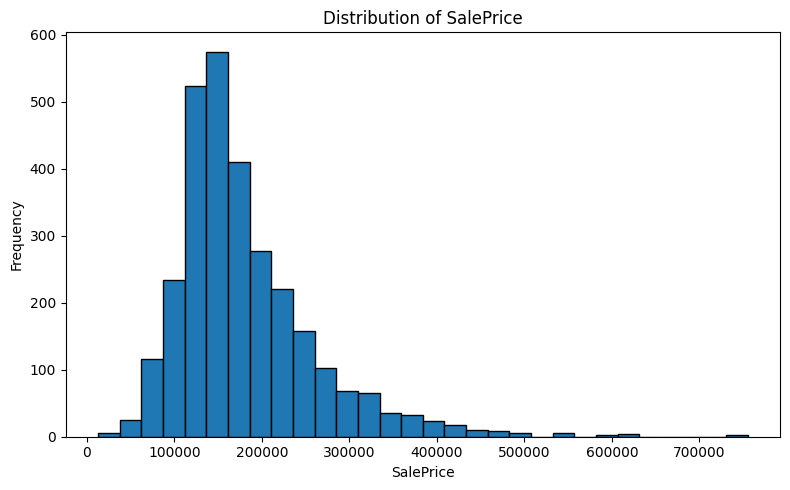


Shape after feature engineering: (2930, 86)

Outlier filtering removed 52 rows.

Train shape: (2302, 85)
Test shape: (576, 85)

Numeric feature count: 42
Categorical feature count: 43

Training: LinearRegression
CV RMSE Mean: 19594.58
CV RMSE Std : 1500.98
Test RMSE   : 20349.19
Test MAE    : 12977.65
Test R2     : 0.9148

Training: Ridge
CV RMSE Mean: 18322.55
CV RMSE Std : 1272.46
Test RMSE   : 20155.82
Test MAE    : 12809.07
Test R2     : 0.9164

Training: Lasso
CV RMSE Mean: 18521.93
CV RMSE Std : 1493.58
Test RMSE   : 20162.58
Test MAE    : 12850.75
Test R2     : 0.9164

Training: RandomForest
CV RMSE Mean: 22334.79
CV RMSE Std : 1967.74
Test RMSE   : 22349.23
Test MAE    : 14598.93
Test R2     : 0.8972

Training: GradientBoosting
CV RMSE Mean: 19192.62
CV RMSE Std : 812.23
Test RMSE   : 20108.70
Test MAE    : 13156.27
Test R2     : 0.9168

Model comparison:
              Model  CV_RMSE_Mean  CV_RMSE_STD     Test_RMSE      Test_MAE  \
4  GradientBoosting  19192.623999   812.23242

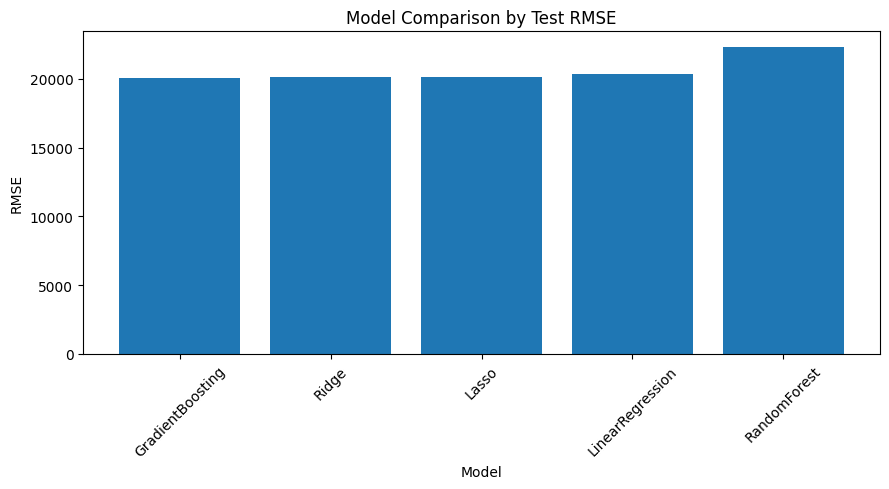


Best model based on Test RMSE: GradientBoosting

Sample predictions:
   Actual      Predicted  AbsoluteError
0  257500  284324.034520   26824.034520
1  186500  192413.450329    5913.450329
2  178740  181145.747275    2405.747275
3  204000  209535.595452    5535.595452
4  232000  237566.926513    5566.926513
5  112500  122257.548269    9757.548269
6  187000  182081.982354    4918.017646
7  146800  147663.818276     863.818276
8  201000  226366.508415   25366.508415
9  214000  229343.727438   15343.727438


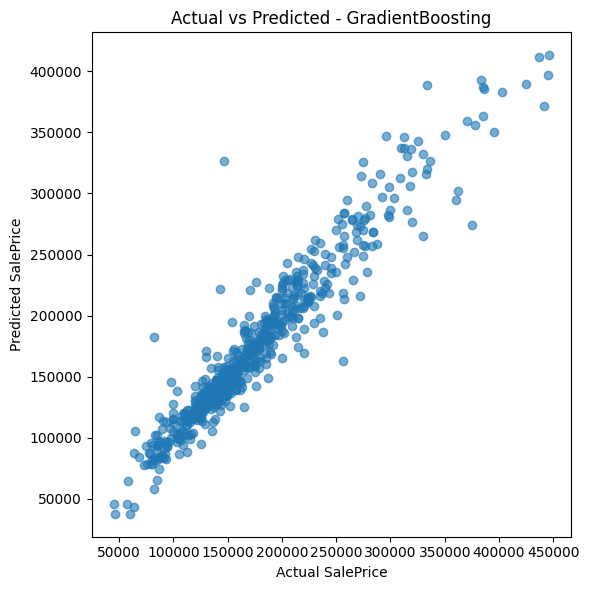

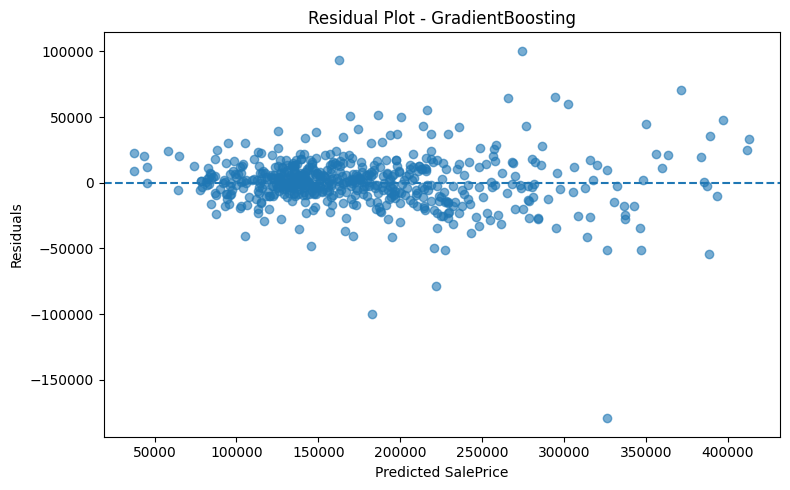


Top 20 important features:
               Feature  Importance
5         Overall Qual    0.430886
17         Gr Liv Area    0.122595
38           TotalBath    0.050837
7           Year Built    0.050791
40      HouseAgeAtSale    0.039762
13       Total Bsmt SF    0.038497
39         GarageScore    0.035663
14          1st Flr SF    0.024543
25          Fireplaces    0.017452
259  Garage Finish_Unf    0.016883
10        BsmtFin SF 1    0.016241
4             Lot Area    0.016078
6         Overall Cond    0.015727
8       Year Remod/Add    0.013015
270      Paved Drive_N    0.010454
227      Central Air_Y    0.008767
226      Central Air_N    0.008007
41   YearsSinceRemodel    0.007868
237    Kitchen Qual_TA    0.007637
28         Garage Area    0.007181


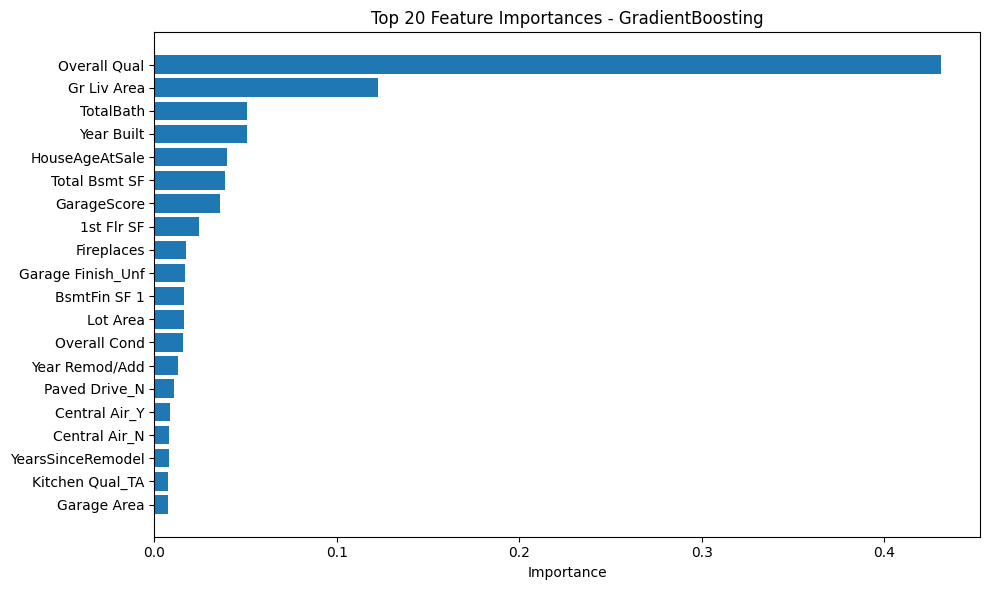


Best model saved to: best_ames_house_price_model.pkl

Single sample prediction demo:
Input row:
     Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
484    485  528275160           60        RL           NaN     12891   Pave   

    Alley Lot Shape Land Contour  ... Misc Feature Misc Val Mo Sold Yr Sold  \
484   NaN       IR1          Lvl  ...          NaN        0       7    2009   

    Sale Type Sale Condition TotalBath GarageScore  HouseAgeAtSale  \
484       WD          Normal       3.5      1932.0               7   

     YearsSinceRemodel  
484                  7  

[1 rows x 85 columns]

Predicted SalePrice: 284324.03
Actual SalePrice   : 257500.00

Saved files:
- model_comparison_results.csv
- prediction_results.csv
- best_ames_house_price_model.pkl


In [1]:
# ============================================================
# HOUSE PRICE PREDICTION - AMES HOUSING DATASET
# Complete end-to-end ML pipeline for COM763 assignment
# ============================================================

# -----------------------------
# 1. IMPORT LIBRARIES
# -----------------------------
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import joblib

# -----------------------------
# 2. CONFIG
# -----------------------------
DATA_PATH = "AmesHousing.csv"   # change if needed
RANDOM_STATE = 42
TEST_SIZE = 0.2

# -----------------------------
# 3. LOAD DATA
# -----------------------------
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Could not find '{DATA_PATH}'. Put AmesHousing.csv in the same folder "
        "or update DATA_PATH."
    )

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print(f"Shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())

print("\nColumn names:")
print(df.columns.tolist())

# -----------------------------
# 4. BASIC DATA CHECKS
# -----------------------------
print("\nData types:")
print(df.dtypes)

print("\nMissing values (top 20):")
print(df.isnull().sum().sort_values(ascending=False).head(20))

print("\nDuplicate rows:", df.duplicated().sum())

# Optional: remove duplicates
df = df.drop_duplicates()
print("Shape after dropping duplicates:", df.shape)

# -----------------------------
# 5. TARGET CHECK
# -----------------------------
TARGET = "SalePrice"

if TARGET not in df.columns:
    raise ValueError(f"Target column '{TARGET}' not found in dataset.")

print("\nTarget summary:")
print(df[TARGET].describe())

# Plot target distribution
plt.figure(figsize=(8, 5))
plt.hist(df[TARGET], bins=30, edgecolor="black")
plt.title("Distribution of SalePrice")
plt.xlabel("SalePrice")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# -----------------------------
# 6. SIMPLE FEATURE ENGINEERING
# -----------------------------
# Create a few useful engineered features if source columns exist.
# These make the project stronger for your report.

def add_engineered_features(dataframe: pd.DataFrame) -> pd.DataFrame:
    df_fe = dataframe.copy()

    if {"TotalBsmtSF", "1st Flr SF", "2nd Flr SF"}.issubset(df_fe.columns):
        df_fe["TotalLivableSF"] = (
            df_fe["TotalBsmtSF"].fillna(0)
            + df_fe["1st Flr SF"].fillna(0)
            + df_fe["2nd Flr SF"].fillna(0)
        )

    if {"Full Bath", "Half Bath", "Bsmt Full Bath", "Bsmt Half Bath"}.issubset(df_fe.columns):
        df_fe["TotalBath"] = (
            df_fe["Full Bath"].fillna(0)
            + 0.5 * df_fe["Half Bath"].fillna(0)
            + df_fe["Bsmt Full Bath"].fillna(0)
            + 0.5 * df_fe["Bsmt Half Bath"].fillna(0)
        )

    if {"Garage Cars", "Garage Area"}.issubset(df_fe.columns):
        df_fe["GarageScore"] = (
            df_fe["Garage Cars"].fillna(0) * df_fe["Garage Area"].fillna(0)
        )

    if {"Year Built", "Yr Sold"}.issubset(df_fe.columns):
        df_fe["HouseAgeAtSale"] = df_fe["Yr Sold"] - df_fe["Year Built"]

    if {"Year Remod/Add", "Yr Sold"}.issubset(df_fe.columns):
        df_fe["YearsSinceRemodel"] = df_fe["Yr Sold"] - df_fe["Year Remod/Add"]

    return df_fe


df = add_engineered_features(df)

print("\nShape after feature engineering:", df.shape)

# -----------------------------
# 7. OPTIONAL OUTLIER FILTERING
# -----------------------------
# Mild, explainable outlier handling for report writing.
# Removes extremely unusual prices and living area values.
# Keep this transparent in your report.

if {"Gr Liv Area", "SalePrice"}.issubset(df.columns):
    before_rows = df.shape[0]
    df = df[
        (df["Gr Liv Area"] < df["Gr Liv Area"].quantile(0.99)) &
        (df["SalePrice"] < df["SalePrice"].quantile(0.99))
    ].copy()
    after_rows = df.shape[0]
    print(f"\nOutlier filtering removed {before_rows - after_rows} rows.")

# -----------------------------
# 8. SPLIT FEATURES/TARGET
# -----------------------------
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)

# -----------------------------
# 9. IDENTIFY COLUMN TYPES
# -----------------------------
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("\nNumeric feature count:", len(numeric_features))
print("Categorical feature count:", len(categorical_features))

# -----------------------------
# 10. PREPROCESSING PIPELINES
# -----------------------------
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# -----------------------------
# 11. DEFINE MODELS
# -----------------------------
# We wrap each model in TransformedTargetRegressor using log1p/expm1.
# This often helps with skewed house prices.

models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=10.0),
    "Lasso": Lasso(alpha=0.0005, max_iter=10000),
    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    )
}

# -----------------------------
# 12. EVALUATION FUNCTION
# -----------------------------
def evaluate_regression(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

# -----------------------------
# 13. TRAIN + CROSS-VALIDATE + TEST
# -----------------------------
results = []
trained_models = {}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for model_name, model in models.items():
    print(f"\n==============================")
    print(f"Training: {model_name}")
    print(f"==============================")

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", TransformedTargetRegressor(
            regressor=model,
            func=np.log1p,
            inverse_func=np.expm1
        ))
    ])

    # Cross-validation on training set
    cv_scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="neg_root_mean_squared_error",
        n_jobs=None
    )
    cv_rmse_mean = -cv_scores.mean()
    cv_rmse_std = cv_scores.std()

    # Fit model
    pipeline.fit(X_train, y_train)

    # Predict on test set
    y_pred = pipeline.predict(X_test)

    test_rmse, test_mae, test_r2 = evaluate_regression(y_test, y_pred)

    results.append({
        "Model": model_name,
        "CV_RMSE_Mean": cv_rmse_mean,
        "CV_RMSE_STD": cv_rmse_std,
        "Test_RMSE": test_rmse,
        "Test_MAE": test_mae,
        "Test_R2": test_r2
    })

    trained_models[model_name] = pipeline

    print(f"CV RMSE Mean: {cv_rmse_mean:.2f}")
    print(f"CV RMSE Std : {cv_rmse_std:.2f}")
    print(f"Test RMSE   : {test_rmse:.2f}")
    print(f"Test MAE    : {test_mae:.2f}")
    print(f"Test R2     : {test_r2:.4f}")

# -----------------------------
# 14. RESULTS TABLE
# -----------------------------
results_df = pd.DataFrame(results).sort_values(by="Test_RMSE")
print("\nModel comparison:")
print(results_df)

# Plot model comparison
plt.figure(figsize=(9, 5))
plt.bar(results_df["Model"], results_df["Test_RMSE"])
plt.title("Model Comparison by Test RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -----------------------------
# 15. SELECT BEST MODEL
# -----------------------------
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print(f"\nBest model based on Test RMSE: {best_model_name}")

# -----------------------------
# 16. FINAL PREDICTIONS + ERROR ANALYSIS
# -----------------------------
y_pred_best = best_model.predict(X_test)

comparison_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_best,
    "AbsoluteError": np.abs(y_test.values - y_pred_best)
})

print("\nSample predictions:")
print(comparison_df.head(10))

# Scatter plot: actual vs predicted
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_best, alpha=0.6)
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title(f"Actual vs Predicted - {best_model_name}")
plt.tight_layout()
plt.show()

# Residual plot
residuals = y_test - y_pred_best

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_best, residuals, alpha=0.6)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted SalePrice")
plt.ylabel("Residuals")
plt.title(f"Residual Plot - {best_model_name}")
plt.tight_layout()
plt.show()

# -----------------------------
# 17. FEATURE IMPORTANCE
# -----------------------------
# We can only extract straightforward feature importances
# from tree-based models here.

def get_feature_names_from_column_transformer(column_transformer):
    feature_names = []

    # Numeric names
    if "num" in column_transformer.named_transformers_:
        feature_names.extend(numeric_features)

    # Categorical one-hot names
    if "cat" in column_transformer.named_transformers_:
        cat_pipeline = column_transformer.named_transformers_["cat"]
        onehot = cat_pipeline.named_steps["onehot"]
        cat_names = onehot.get_feature_names_out(categorical_features).tolist()
        feature_names.extend(cat_names)

    return feature_names


if best_model_name in ["RandomForest", "GradientBoosting"]:
    fitted_preprocessor = best_model.named_steps["preprocessor"]
    transformed_regressor = best_model.named_steps["model"]
    regressor = transformed_regressor.regressor_

    feature_names = get_feature_names_from_column_transformer(fitted_preprocessor)

    if hasattr(regressor, "feature_importances_"):
        importances = regressor.feature_importances_
        fi_df = pd.DataFrame({
            "Feature": feature_names,
            "Importance": importances
        }).sort_values(by="Importance", ascending=False)

        print("\nTop 20 important features:")
        print(fi_df.head(20))

        plt.figure(figsize=(10, 6))
        top_n = 20
        plt.barh(fi_df["Feature"].head(top_n)[::-1], fi_df["Importance"].head(top_n)[::-1])
        plt.title(f"Top {top_n} Feature Importances - {best_model_name}")
        plt.xlabel("Importance")
        plt.tight_layout()
        plt.show()

# -----------------------------
# 18. SAVE BEST MODEL
# -----------------------------
MODEL_PATH = "best_ames_house_price_model.pkl"
joblib.dump(best_model, MODEL_PATH)
print(f"\nBest model saved to: {MODEL_PATH}")

# -----------------------------
# 19. LOAD MODEL AND PREDICT ONE SAMPLE
# -----------------------------
loaded_model = joblib.load(MODEL_PATH)

sample_input = X_test.iloc[[0]].copy()
sample_prediction = loaded_model.predict(sample_input)[0]

print("\nSingle sample prediction demo:")
print("Input row:")
print(sample_input)
print(f"\nPredicted SalePrice: {sample_prediction:.2f}")
print(f"Actual SalePrice   : {y_test.iloc[0]:.2f}")

# -----------------------------
# 20. EXPORT RESULTS
# -----------------------------
results_df.to_csv("model_comparison_results.csv", index=False)
comparison_df.to_csv("prediction_results.csv", index=False)

print("\nSaved files:")
print("- model_comparison_results.csv")
print("- prediction_results.csv")
print("- best_ames_house_price_model.pkl")